# 01 — Baseline Credit Risk Model

This notebook establishes the baseline environment for the Adaptive Model Risk project.

The objective is to create a simple credit-risk model that performs well under its original development conditions. Later notebooks will expose the same model to changing data distributions and changing relationships between borrower characteristics and default risk.

## Research Question

Can a predictive model that performs well when developed become unreliable when the environment in which it operates changes?

## Experiment Structure

This notebook will:

1. Generate a synthetic borrower population.
2. Define a controlled probability-of-default process.
3. Create borrower default outcomes.
4. Explore the generated data.
5. Train a logistic regression model.
6. Evaluate discrimination and calibration.
7. Establish baseline performance metrics for future monitoring.

## 1. Setup

We begin by importing the libraries used for data generation, analysis, visualization, model development, and model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    brier_score_loss,
    log_loss,
)
from sklearn.calibration import calibration_curve

In [2]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: c:\Users\Omid Elmi\Documents\GitHub\adaptive-model-risk
Figures directory: c:\Users\Omid Elmi\Documents\GitHub\adaptive-model-risk\figures


## 2. Synthetic Borrower Population

To study model deterioration in a controlled setting, we generate a synthetic population of borrowers.

The baseline dataset represents the environment in which the credit-risk model is originally developed. Each borrower has several characteristics that may be associated with probability of default.

The initial features are:

| Variable | Description |
|---|---|
| `age` | Borrower's age in years |
| `annual_income` | Annual income in U.S. dollars |
| `credit_score` | Synthetic credit score |
| `debt_to_income` | Debt-to-income ratio |
| `loan_amount` | Requested loan amount in U.S. dollars |
| `unemployment_rate` | Macroeconomic unemployment rate at observation time |

The outcome variable, `default`, will be generated later from a known probability-of-default mechanism.

Because the data-generating process is controlled, later experiments can separately modify the distribution of borrower characteristics, $P(X)$, and the relationship between borrower characteristics and default, $P(Y|X)$.

In [5]:
N_BORROWERS = 50_000

In [6]:
age = rng.normal(
    loc=42,
    scale=12,
    size=N_BORROWERS,
)

age = np.clip(age, 18, 80)
age = np.round(age).astype(int)

In [7]:
pd.Series(age).describe()

count    50000.000000
mean        42.095600
std         11.777329
min         18.000000
25%         34.000000
50%         42.000000
75%         50.000000
max         80.000000
dtype: float64

In [8]:
annual_income = rng.lognormal(
    mean=np.log(70_000),
    sigma=0.45,
    size=N_BORROWERS,
)

annual_income = np.clip(
    annual_income,
    20_000,
    300_000,
)

In [9]:
pd.Series(annual_income).describe()

count     50000.000000
mean      77246.703441
std       36721.592909
min       20000.000000
25%       51466.873042
50%       69579.381985
75%       94628.092847
max      300000.000000
dtype: float64

In [10]:
credit_score = rng.normal(
    loc=700,
    scale=55,
    size=N_BORROWERS,
)

credit_score = np.clip(
    credit_score,
    500,
    850,
)

credit_score = np.round(credit_score).astype(int)

In [11]:
pd.Series(credit_score).describe()

count    50000.000000
mean       699.858280
std         55.095346
min        500.000000
25%        663.000000
50%        700.000000
75%        737.000000
max        850.000000
dtype: float64

In [12]:
debt_to_income = rng.beta(
    a=2.5,
    b=5.0,
    size=N_BORROWERS,
)

debt_to_income = np.clip(
    debt_to_income,
    0.02,
    0.90,
)

In [13]:
pd.Series(debt_to_income).describe()

count    50000.000000
mean         0.333762
std          0.160968
min          0.020000
25%          0.210009
50%          0.318949
75%          0.441109
max          0.900000
dtype: float64

In [14]:
loan_to_income_ratio = rng.uniform(
    low=0.05,
    high=0.60,
    size=N_BORROWERS,
)

loan_amount = annual_income * loan_to_income_ratio

loan_amount = np.clip(
    loan_amount,
    2_000,
    75_000,
)

In [15]:
pd.Series(loan_amount).describe()

count    50000.000000
mean     24790.387029
std      16820.033412
min       2000.000000
25%      11887.022382
50%      21075.451701
75%      33583.604688
max      75000.000000
dtype: float64

In [16]:
unemployment_rate = rng.normal(
    loc=0.045,
    scale=0.005,
    size=N_BORROWERS,
)

unemployment_rate = np.clip(
    unemployment_rate,
    0.025,
    0.070,
)

In [17]:
borrowers = pd.DataFrame(
    {
        "age": age,
        "annual_income": annual_income,
        "credit_score": credit_score,
        "debt_to_income": debt_to_income,
        "loan_amount": loan_amount,
        "unemployment_rate": unemployment_rate,
    }
)

In [18]:
borrowers.head()

,age,annual_income,credit_score,debt_to_income,loan_amount,unemployment_rate
0,46,98973.413627,613,0.235645,19435.012128,0.038581
1,30,30530.856139,831,0.351954,2000.000000,0.042690
2,51,62843.611780,799,0.220851,34399.546813,0.036856
3,53,42850.142923,654,0.331056,24404.223160,0.040896
4,19,253950.431324,788,0.354836,26682.410477,0.046602


In [19]:
borrowers.shape

(50000, 6)

In [20]:
borrowers.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                50000 non-null  int64  
 1   annual_income      50000 non-null  float64
 2   credit_score       50000 non-null  int64  
 3   debt_to_income     50000 non-null  float64
 4   loan_amount        50000 non-null  float64
 5   unemployment_rate  50000 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 2.3 MB


In [21]:
borrowers.isna().sum()

age                  0
annual_income        0
credit_score         0
debt_to_income       0
loan_amount          0
unemployment_rate    0
dtype: int64

## 3. Baseline Probability of Default

We now define the baseline relationship between borrower characteristics and default risk.

For borrower $(i)$, let

$[
p_i = P(Y_i = 1 \mid X_i)
]$

where $(Y_i = 1)$ represents default.

We use a logistic data-generating process:

$[
p_i = \frac{1}{1 + e^{-z_i}}
]$

where $(z_i)$ is a linear combination of borrower and economic characteristics.

The baseline environment assumes that default risk:

- decreases as credit score increases;
- increases as debt-to-income ratio increases;
- increases as loan burden relative to income increases;
- increases as unemployment rises.

This probability-of-default equation represents the underlying relationship $(P(Y \mid X))$ in the baseline environment.

In [22]:
borrowers["loan_to_income"] = (
    borrowers["loan_amount"] / borrowers["annual_income"]
)

In [23]:
borrowers["loan_to_income"].describe()

count    50000.000000
mean         0.323008
std          0.156915
min          0.050002
25%          0.188061
50%          0.322987
75%          0.457786
max          0.599992
Name: loan_to_income, dtype: float64

In [24]:
borrowers.head()

,age,annual_income,credit_score,debt_to_income,loan_amount,unemployment_rate,loan_to_income
0,46,98973.413627,613,0.235645,19435.012128,0.038581,0.196366
1,30,30530.856139,831,0.351954,2000.000000,0.042690,0.065507
2,51,62843.611780,799,0.220851,34399.546813,0.036856,0.547383
3,53,42850.142923,654,0.331056,24404.223160,0.040896,0.569525
4,19,253950.431324,788,0.354836,26682.410477,0.046602,0.105069


In [25]:
credit_score_effect = (
    borrowers["credit_score"] - 700
) / 50

dti_effect = (
    borrowers["debt_to_income"] - 0.33
) / 0.15

loan_burden_effect = (
    borrowers["loan_to_income"] - 0.30
) / 0.15

unemployment_effect = (
    borrowers["unemployment_rate"] - 0.045
) / 0.01

In [26]:
log_odds = (
    -3.2
    - 0.65 * credit_score_effect
    + 1.00 * dti_effect
    + 0.65 * loan_burden_effect
    + 0.45 * unemployment_effect
)

In [27]:
default_probability = 1 / (1 + np.exp(-log_odds))

In [28]:
default_probability[:10]

0    0.031191
1    0.002796
2    0.010888
3    0.166354
4    0.007026
5    0.523980
6    0.112361
7    0.400621
8    0.107328
9    0.041015
dtype: float64

In [29]:
borrowers["true_default_probability"] = default_probability

In [30]:
borrowers[
    [
        "credit_score",
        "debt_to_income",
        "loan_to_income",
        "unemployment_rate",
        "true_default_probability",
    ]
].head(10)

,credit_score,debt_to_income,loan_to_income,unemployment_rate,true_default_probability
0,613,0.235645,0.196366,0.038581,0.031191
1,831,0.351954,0.065507,0.042690,0.002796
2,799,0.220851,0.547383,0.036856,0.010888
3,654,0.331056,0.569525,0.040896,0.166354
4,788,0.354836,0.105069,0.046602,0.007026
5,637,0.572824,0.479764,0.046760,0.523980
6,663,0.364323,0.401704,0.044614,0.112361
7,701,0.575387,0.587581,0.043400,0.400621
8,652,0.260038,0.482445,0.047966,0.107328
9,733,0.404822,0.295510,0.044949,0.041015


In [31]:
borrowers["true_default_probability"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    50000.000000
mean         0.091880
std          0.126329
min          0.000320
1%           0.001816
5%           0.004377
25%          0.016136
50%          0.042191
75%          0.110875
95%          0.367508
99%          0.617862
max          0.958007
Name: true_default_probability, dtype: float64

In [32]:
borrowers.groupby(
    pd.qcut(
        borrowers["credit_score"],
        q=5,
        duplicates="drop",
    ),
    observed=True,
)["true_default_probability"].mean()

credit_score
(499.999, 653.0]    0.173149
(653.0, 686.0]      0.108226
(686.0, 714.0]      0.081049
(714.0, 746.0]      0.058738
(746.0, 850.0]      0.036295
Name: true_default_probability, dtype: float64

In [33]:
borrowers.groupby(
    pd.qcut(
        borrowers["debt_to_income"],
        q=5,
        duplicates="drop",
    ),
    observed=True,
)["true_default_probability"].mean()

debt_to_income
(0.019, 0.186]    0.018704
(0.186, 0.277]    0.036064
(0.277, 0.364]    0.061075
(0.364, 0.474]    0.104281
(0.474, 0.9]      0.239278
Name: true_default_probability, dtype: float64

In [34]:
borrowers["default"] = rng.binomial(
    n=1,
    p=borrowers["true_default_probability"],
)

In [35]:
baseline_default_rate = borrowers["default"].mean()

print(
    f"Baseline default rate: "
    f"{baseline_default_rate:.2%}"
)

Baseline default rate: 9.04%


In [36]:
print(
    f"Average true default probability: "
    f"{borrowers['true_default_probability'].mean():.2%}"
)

print(
    f"Observed default rate: "
    f"{borrowers['default'].mean():.2%}"
)

Average true default probability: 9.19%
Observed default rate: 9.04%


## 4. Baseline Data Exploration

Before training the model, we examine the synthetic baseline population and verify that the simulated relationships are economically sensible.

Because the true probability of default is known in this synthetic environment, we can compare borrower characteristics with both:

- the underlying probability of default; and
- the observed default outcome.

These exploratory checks help verify that the data-generating process behaves as intended.

In [37]:
borrowers[
    [
        "age",
        "annual_income",
        "credit_score",
        "debt_to_income",
        "loan_amount",
        "loan_to_income",
        "unemployment_rate",
        "true_default_probability",
        "default",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,42.095600,11.777329,18.000000,34.000000,42.000000,50.000000,80.000000
annual_income,50000.0,77246.703441,36721.592909,20000.000000,51466.873042,69579.381985,94628.092847,300000.000000
credit_score,50000.0,699.858280,55.095346,500.000000,663.000000,700.000000,737.000000,850.000000
debt_to_income,50000.0,0.333762,0.160968,0.020000,0.210009,0.318949,0.441109,0.900000
loan_amount,50000.0,24790.387029,16820.033412,2000.000000,11887.022382,21075.451701,33583.604688,75000.000000
loan_to_income,50000.0,0.323008,0.156915,0.050002,0.188061,0.322987,0.457786,0.599992
unemployment_rate,50000.0,0.044956,0.005015,0.025000,0.041576,0.044976,0.048367,0.067308
true_default_probability,50000.0,0.091880,0.126329,0.000320,0.016136,0.042191,0.110875,0.958007
default,50000.0,0.090380,0.286728,0.000000,0.000000,0.000000,0.000000,1.000000


### 4.1 Credit Score Distribution

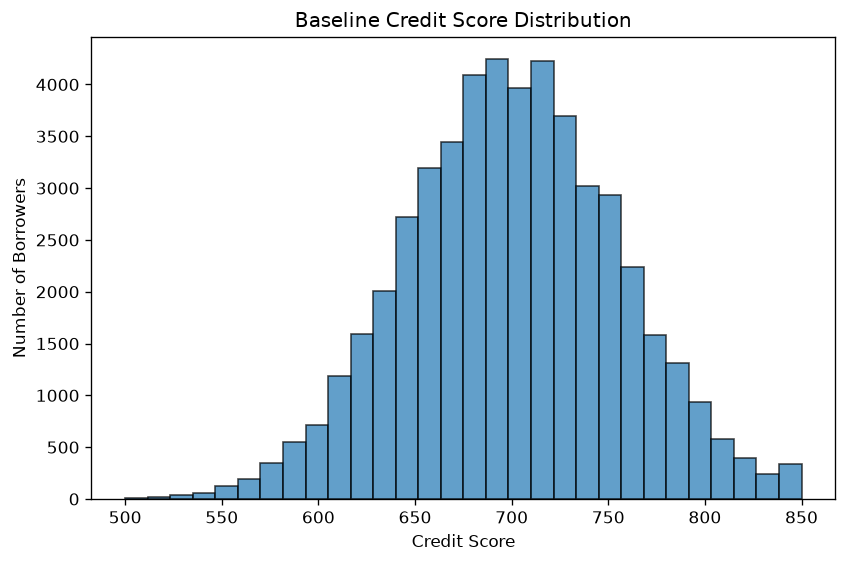

In [38]:
fig, ax = plt.subplots()

ax.hist(
    borrowers["credit_score"],
    bins=30,
    edgecolor="black",
    alpha=0.7,
)

ax.set_title("Baseline Credit Score Distribution")
ax.set_xlabel("Credit Score")
ax.set_ylabel("Number of Borrowers")

plt.show()

### 4.2 Debt-to-Income Distribution

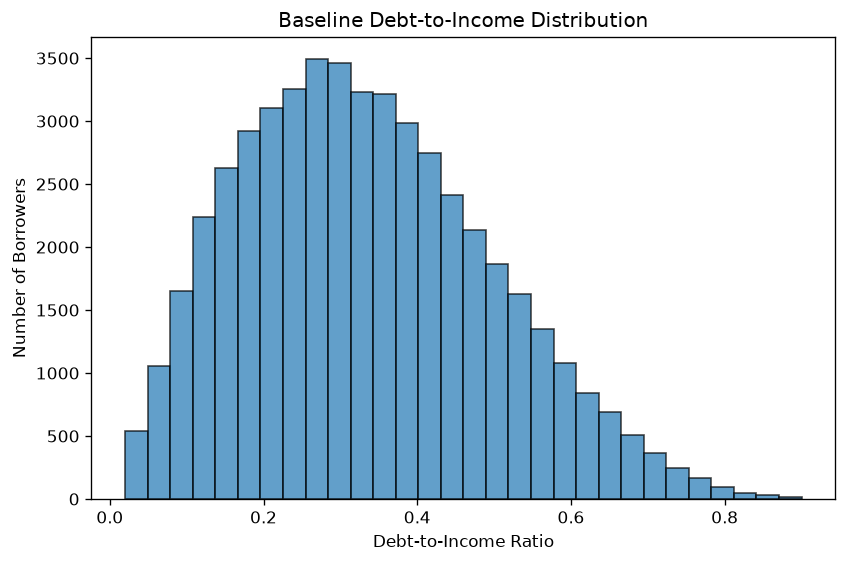

In [39]:
fig, ax = plt.subplots()

ax.hist(
    borrowers["debt_to_income"],
    bins=30,
    edgecolor="black",
    alpha=0.7,
)

ax.set_title("Baseline Debt-to-Income Distribution")
ax.set_xlabel("Debt-to-Income Ratio")
ax.set_ylabel("Number of Borrowers")

plt.show()

### 4.3 Default Risk by Credit Score

Higher credit scores should correspond to lower probability of default under the baseline data-generating process.

In [40]:
credit_score_summary = (
    borrowers
    .assign(
        credit_score_bin=pd.cut(
            borrowers["credit_score"],
            bins=np.arange(500, 876, 25),
            include_lowest=True,
        )
    )
    .groupby(
        "credit_score_bin",
        observed=True,
    )
    .agg(
        average_credit_score=("credit_score", "mean"),
        true_default_probability=("true_default_probability", "mean"),
        observed_default_rate=("default", "mean"),
        borrower_count=("default", "size"),
    )
    .reset_index()
)

credit_score_summary

,credit_score_bin,average_credit_score,true_default_probability,observed_default_rate,borrower_count
0,"(499.999, 525.0]",513.078947,0.483637,0.500000,38
1,"(525.0, 550.0]",540.176000,0.352302,0.344000,125
2,"(550.0, 575.0]",565.219858,0.258101,0.215130,423
3,"(575.0, 600.0]",589.446585,0.228841,0.239054,1142
4,"(600.0, 625.0]",614.244103,0.178230,0.177836,2671
5,"(625.0, 650.0]",639.109394,0.148140,0.144978,4918
6,"(650.0, 675.0]",663.689785,0.117873,0.114246,7195
7,"(675.0, 700.0]",688.096925,0.091609,0.089725,8749
8,"(700.0, 725.0]",712.673073,0.069688,0.068749,8742
9,"(725.0, 750.0]",737.538965,0.054596,0.054039,7032


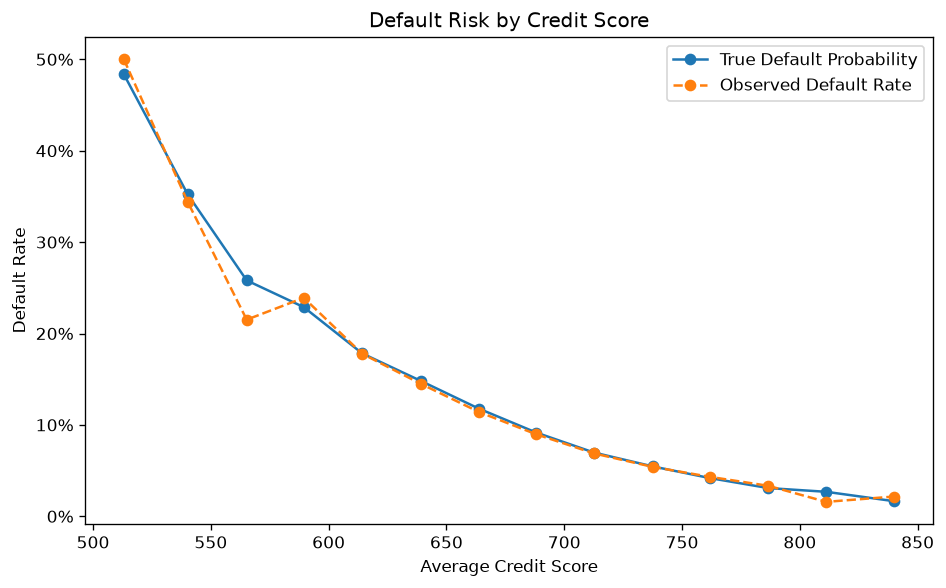

In [41]:
fig, ax = plt.subplots()

ax.plot(
    credit_score_summary["average_credit_score"],
    credit_score_summary["true_default_probability"],
    marker="o",
    label="True Default Probability",
)

ax.plot(
    credit_score_summary["average_credit_score"],
    credit_score_summary["observed_default_rate"],
    marker="o",
    linestyle="--",
    label="Observed Default Rate",
)

ax.set_title("Default Risk by Credit Score")
ax.set_xlabel("Average Credit Score")
ax.set_ylabel("Default Rate")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "baseline_default_risk_by_credit_score.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 4.4 Default Risk by Debt-to-Income Ratio

Higher debt-to-income ratios should correspond to greater probability of default in the baseline environment.

In [42]:
dti_summary = (
    borrowers
    .assign(
        dti_bin=pd.qcut(
            borrowers["debt_to_income"],
            q=10,
            duplicates="drop",
        )
    )
    .groupby(
        "dti_bin",
        observed=True,
    )
    .agg(
        average_dti=("debt_to_income", "mean"),
        true_default_probability=("true_default_probability", "mean"),
        observed_default_rate=("default", "mean"),
        borrower_count=("default", "size"),
    )
    .reset_index()
)

dti_summary

,dti_bin,average_dti,true_default_probability,observed_default_rate,borrower_count
0,"(0.019, 0.131]",0.090872,0.014641,0.0154,5000
1,"(0.131, 0.186]",0.159854,0.022767,0.0194,5000
2,"(0.186, 0.233]",0.209925,0.030319,0.0318,5000
3,"(0.233, 0.277]",0.255254,0.041809,0.0394,5000
4,"(0.277, 0.319]",0.297623,0.052990,0.0498,5000
5,"(0.319, 0.364]",0.341594,0.069160,0.0676,5000
6,"(0.364, 0.414]",0.388558,0.089079,0.0900,5000
7,"(0.414, 0.474]",0.442428,0.119483,0.1164,5000
8,"(0.474, 0.557]",0.512774,0.172277,0.1704,5000
9,"(0.557, 0.9]",0.638736,0.306279,0.3036,5000


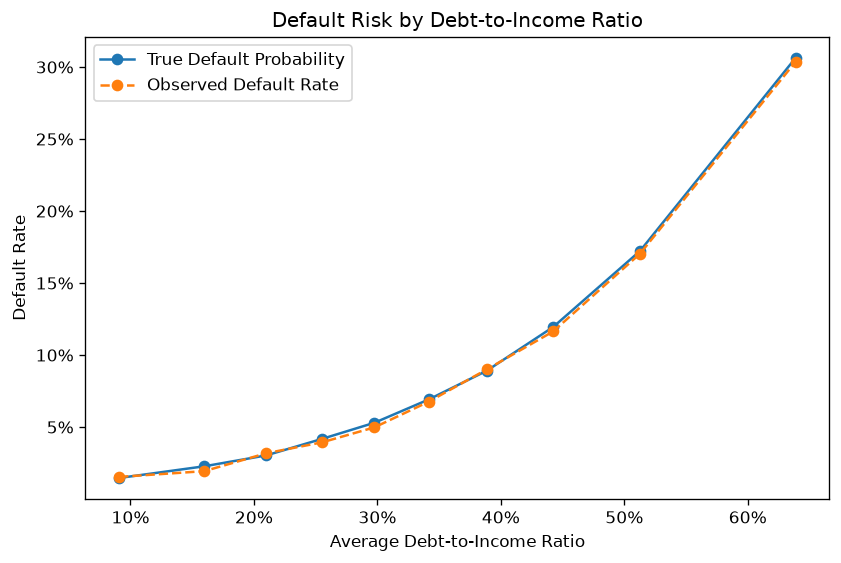

In [43]:
fig, ax = plt.subplots()

ax.plot(
    dti_summary["average_dti"],
    dti_summary["true_default_probability"],
    marker="o",
    label="True Default Probability",
)

ax.plot(
    dti_summary["average_dti"],
    dti_summary["observed_default_rate"],
    marker="o",
    linestyle="--",
    label="Observed Default Rate",
)

ax.set_title("Default Risk by Debt-to-Income Ratio")
ax.set_xlabel("Average Debt-to-Income Ratio")
ax.set_ylabel("Default Rate")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend()

plt.show()

### 4.5 Distribution of Baseline Default Risk

The synthetic population contains borrowers with heterogeneous levels of underlying default risk rather than assigning the same probability to every borrower.

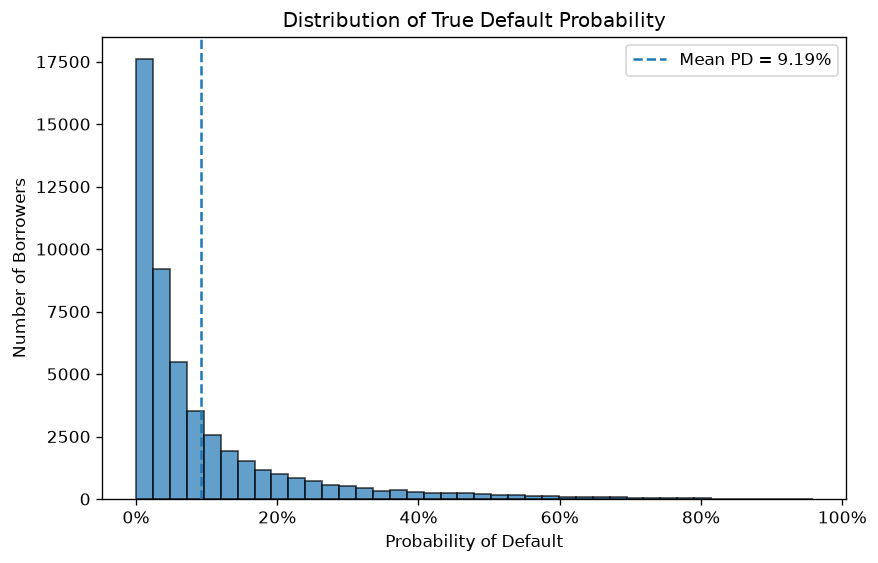

In [44]:
fig, ax = plt.subplots()

ax.hist(
    borrowers["true_default_probability"],
    bins=40,
    edgecolor="black",
    alpha=0.7,
)

ax.axvline(
    borrowers["true_default_probability"].mean(),
    linestyle="--",
    label=(
        "Mean PD = "
        f"{borrowers['true_default_probability'].mean():.2%}"
    ),
)

ax.set_title("Distribution of True Default Probability")
ax.set_xlabel("Probability of Default")
ax.set_ylabel("Number of Borrowers")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend()

plt.show()

In [45]:
borrowers.groupby(
    pd.qcut(
        borrowers["credit_score"],
        q=5,
        duplicates="drop",
    ),
    observed=True,
).agg(
    borrower_count=("default", "size"),
    observed_defaults=("default", "sum"),
    observed_default_rate=("default", "mean"),
)

,borrower_count,observed_defaults,observed_default_rate
credit_score,,,
"(499.999, 653.0]",10067,1720,0.170855
"(653.0, 686.0]",10231,1054,0.103020
"(686.0, 714.0]",10012,827,0.082601
"(714.0, 746.0]",9694,553,0.057046
"(746.0, 850.0]",9996,365,0.036515


## 5. Baseline Model Development

We now train a predictive credit-risk model using the synthetic borrower data.

The model does not have access to the true probability-of-default equation used to generate the data. It observes only borrower characteristics and realized default outcomes.

A logistic regression model is used as the baseline because it is interpretable, widely used for binary risk modeling, and allows the project to focus on model deterioration rather than model complexity.

In [46]:
MODEL_FEATURES = [
    "credit_score",
    "debt_to_income",
    "loan_to_income",
    "unemployment_rate",
]

In [47]:
X = borrowers[MODEL_FEATURES]
y = borrowers["default"]

In [48]:
X.head()

,credit_score,debt_to_income,loan_to_income,unemployment_rate
0,613,0.235645,0.196366,0.038581
1,831,0.351954,0.065507,0.042690
2,799,0.220851,0.547383,0.036856
3,654,0.331056,0.569525,0.040896
4,788,0.354836,0.105069,0.046602


In [49]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: default, dtype: int64

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y,
)

In [51]:
print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")

print(f"Training default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

Training observations: 35,000
Test observations: 15,000
Training default rate: 9.04%
Test default rate: 9.04%


In [52]:
baseline_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

In [53]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['credit_score','debt_to_income','loan_to_income','unemployment_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [54]:
y_test_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

In [55]:
y_test_pred_proba[:10]

array([0.12656518, 0.11591315, 0.02548369, 0.02354556, 0.01486159,
       0.00183806, 0.01894174, 0.01493337, 0.00138368, 0.28631446])

In [56]:
baseline_auc = roc_auc_score(
    y_test,
    y_test_pred_proba,
)

baseline_brier = brier_score_loss(
    y_test,
    y_test_pred_proba,
)

baseline_log_loss = log_loss(
    y_test,
    y_test_pred_proba,
)

In [57]:
print(f"Baseline ROC AUC:    {baseline_auc:.3f}")
print(f"Baseline Brier:      {baseline_brier:.4f}")
print(f"Baseline Log Loss:   {baseline_log_loss:.4f}")

Baseline ROC AUC:    0.835
Baseline Brier:      0.0669
Baseline Log Loss:   0.2337


In [58]:
baseline_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC AUC",
            "Brier Score",
            "Log Loss",
        ],
        "value": [
            baseline_auc,
            baseline_brier,
            baseline_log_loss,
        ],
    }
)

baseline_metrics

,metric,value
0,ROC AUC,0.835161
1,Brier Score,0.066881
2,Log Loss,0.233697


In [59]:
logistic_model = baseline_model.named_steps["logistic_regression"]

coefficient_table = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "coefficient": logistic_model.coef_[0],
    }
).sort_values(
    "coefficient",
    ascending=False,
)

coefficient_table

,feature,coefficient
1,debt_to_income,1.074438
2,loan_to_income,0.686034
3,unemployment_rate,0.224321
0,credit_score,-0.724887


## 6. Baseline Model Evaluation

The baseline model is evaluated on the held-out test sample.

We examine two distinct aspects of model performance:

1. **Discrimination** — whether the model ranks higher-risk borrowers above lower-risk borrowers.
2. **Calibration** — whether predicted probabilities correspond to observed default frequencies.

These dimensions will later be monitored separately as the operating environment changes.

### 6.1 Discrimination: ROC Curve

The Receiver Operating Characteristic (ROC) curve shows the tradeoff between the true-positive rate and false-positive rate across classification thresholds.

The Area Under the ROC Curve (AUC) summarizes the model's ability to rank defaulting borrowers above non-defaulting borrowers.

In [60]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_pred_proba,
)

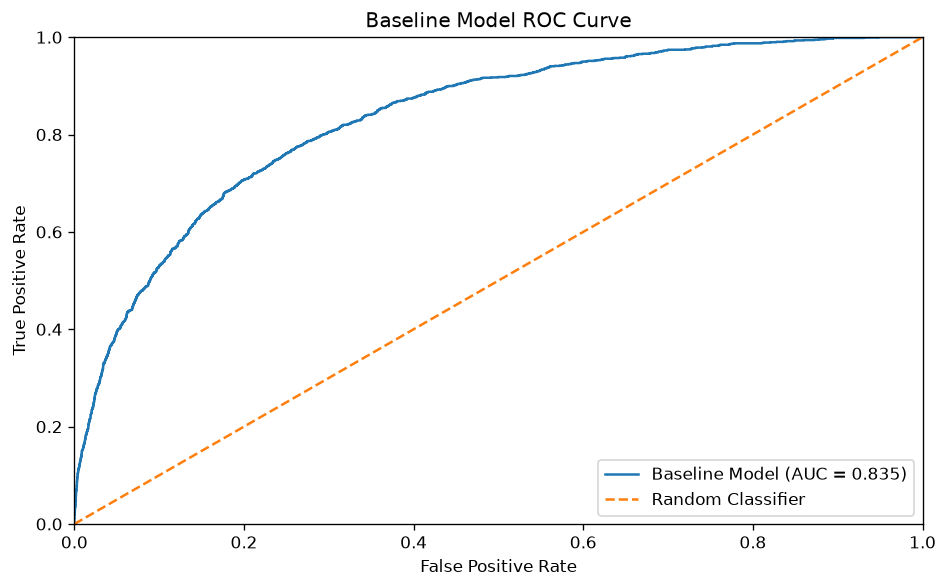

In [61]:
fig, ax = plt.subplots()

ax.plot(
    fpr,
    tpr,
    label=f"Baseline Model (AUC = {baseline_auc:.3f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

ax.set_title("Baseline Model ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "baseline_roc_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 6.2 Calibration

A well-calibrated model assigns probabilities that correspond to observed outcome frequencies.

For example, among borrowers assigned approximately 10% predicted default probability, roughly 10% should actually default.

The calibration curve compares predicted probabilities with observed default rates.

In [62]:
fraction_of_positives, mean_predicted_probability = calibration_curve(
    y_test,
    y_test_pred_proba,
    n_bins=10,
    strategy="quantile",
)

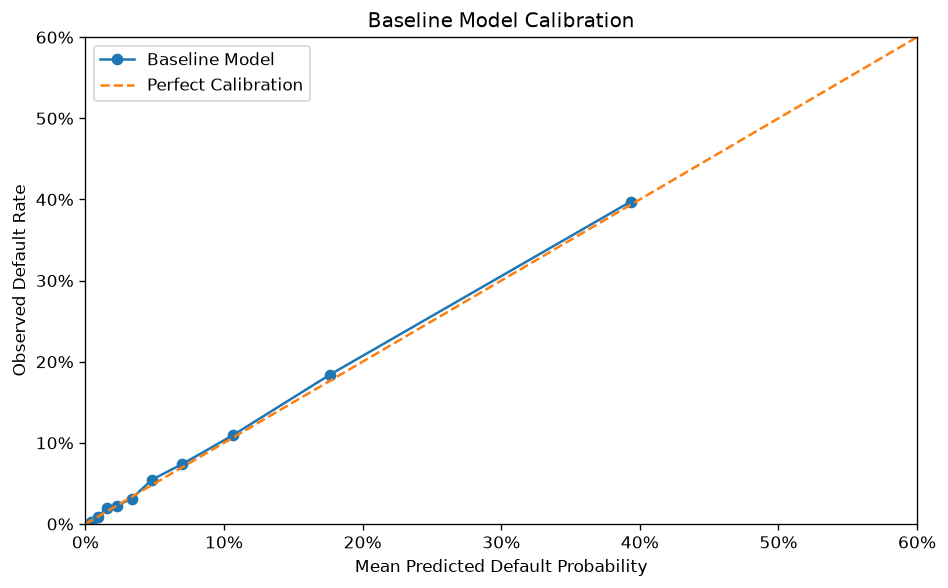

In [63]:
fig, ax = plt.subplots()

ax.plot(
    mean_predicted_probability,
    fraction_of_positives,
    marker="o",
    label="Baseline Model",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

ax.set_title("Baseline Model Calibration")
ax.set_xlabel("Mean Predicted Default Probability")
ax.set_ylabel("Observed Default Rate")

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "baseline_calibration.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [64]:
calibration_table = pd.DataFrame(
    {
        "mean_predicted_probability": mean_predicted_probability,
        "observed_default_rate": fraction_of_positives,
    }
)

calibration_table

,mean_predicted_probability,observed_default_rate
0,0.003965,0.002667
1,0.009198,0.008667
2,0.015279,0.019333
3,0.022768,0.022667
4,0.033400,0.031333
5,0.048104,0.054667
6,0.070071,0.074000
7,0.106410,0.109333
8,0.176436,0.184000
9,0.393492,0.397333


In [65]:
baseline_calibration_error = np.mean(
    np.abs(
        fraction_of_positives
        - mean_predicted_probability
    )
)

print(
    f"Baseline Calibration Error: "
    f"{baseline_calibration_error:.4f}"
)

Baseline Calibration Error: 0.0033


In [66]:
baseline_metrics = pd.DataFrame(
    {
        "metric": [
            "ROC AUC",
            "Brier Score",
            "Log Loss",
            "Calibration Error",
        ],
        "value": [
            baseline_auc,
            baseline_brier,
            baseline_log_loss,
            baseline_calibration_error,
        ],
    }
)

baseline_metrics

,metric,value
0,ROC AUC,0.835161
1,Brier Score,0.066881
2,Log Loss,0.233697
3,Calibration Error,0.003287


In [67]:
test_results = X_test.copy()

test_results["observed_default"] = y_test

test_results["predicted_default_probability"] = (
    y_test_pred_proba
)

test_results["true_default_probability"] = borrowers.loc[
    X_test.index,
    "true_default_probability",
]

In [68]:
test_results.head()

,credit_score,debt_to_income,loan_to_income,unemployment_rate,observed_default,predicted_default_probability,true_default_probability
13872,728,0.453551,0.445264,0.049902,0,0.126565,0.131214
16912,709,0.458667,0.443659,0.041463,0,0.115913,0.119636
13251,741,0.550513,0.105973,0.034180,0,0.025484,0.026842
29566,684,0.190732,0.258624,0.054227,0,0.023546,0.024494
10690,748,0.162401,0.411586,0.051845,0,0.014862,0.015524


In [69]:
probability_mae = np.mean(
    np.abs(
        test_results["predicted_default_probability"]
        - test_results["true_default_probability"]
    )
)

print(
    f"Mean absolute error vs. true PD: "
    f"{probability_mae:.4f}"
)

Mean absolute error vs. true PD: 0.0022


### 6.3 Predicted Probability vs. True Synthetic Risk

Because the experiment uses a known synthetic data-generating process, the model's estimated default probabilities can be directly compared with the underlying true probabilities.

This comparison would generally not be available in a real production environment, but it provides a useful benchmark for controlled model-deterioration experiments.

In [70]:
true_vs_predicted = (
    test_results
    .assign(
        risk_bin=pd.qcut(
            test_results["true_default_probability"],
            q=10,
            duplicates="drop",
        )
    )
    .groupby(
        "risk_bin",
        observed=True,
    )
    .agg(
        true_probability=("true_default_probability", "mean"),
        predicted_probability=(
            "predicted_default_probability",
            "mean",
        ),
        observed_default_rate=("observed_default", "mean"),
    )
    .reset_index()
)

true_vs_predicted

,risk_bin,true_probability,predicted_probability,observed_default_rate
0,"(-0.000526, 0.0068]",0.004169,0.003966,0.002667
1,"(0.0068, 0.0126]",0.009622,0.009198,0.008667
2,"(0.0126, 0.0195]",0.015937,0.015280,0.020000
3,"(0.0195, 0.0285]",0.023702,0.022767,0.022000
4,"(0.0285, 0.0412]",0.034705,0.033404,0.030667
5,"(0.0412, 0.0596]",0.049854,0.048109,0.056000
6,"(0.0596, 0.0873]",0.072421,0.070068,0.072667
7,"(0.0873, 0.136]",0.109757,0.106414,0.110667
8,"(0.136, 0.241]",0.181256,0.176435,0.183333
9,"(0.241, 0.925]",0.399905,0.393484,0.397333


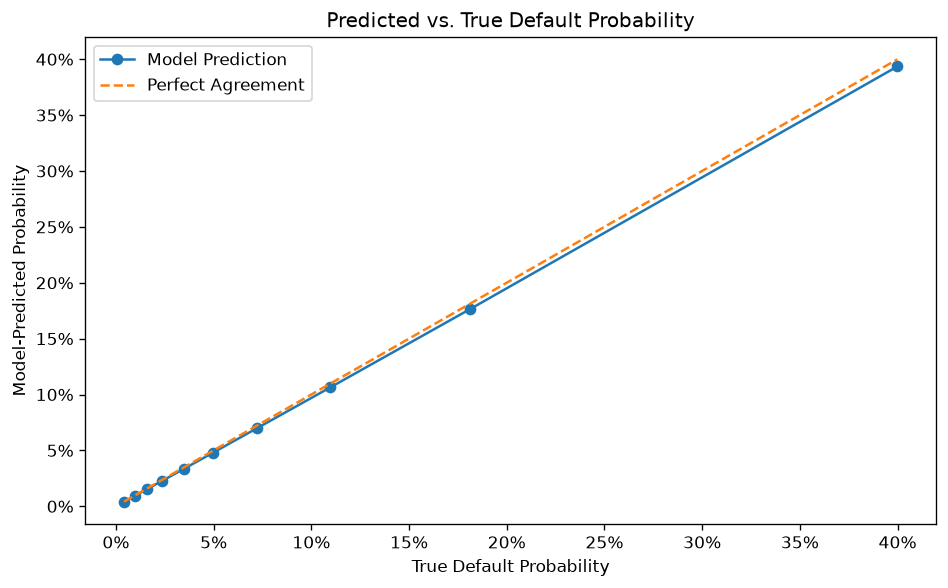

In [71]:
fig, ax = plt.subplots()

ax.plot(
    true_vs_predicted["true_probability"],
    true_vs_predicted["predicted_probability"],
    marker="o",
    label="Model Prediction",
)

ax.plot(
    true_vs_predicted["true_probability"],
    true_vs_predicted["true_probability"],
    linestyle="--",
    label="Perfect Agreement",
)

ax.set_title("Predicted vs. True Default Probability")
ax.set_xlabel("True Default Probability")
ax.set_ylabel("Model-Predicted Probability")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "baseline_true_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 6.4 Baseline Monitoring Reference

The following metrics form the baseline reference against which future environments will be compared.

In [72]:
baseline_summary = pd.DataFrame(
    {
        "Metric": [
            "ROC AUC",
            "Brier Score",
            "Log Loss",
            "Calibration Error",
            "MAE vs. True PD",
        ],
        "Baseline Value": [
            baseline_auc,
            baseline_brier,
            baseline_log_loss,
            baseline_calibration_error,
            probability_mae,
        ],
    }
)

baseline_summary

,Metric,Baseline Value
0,ROC AUC,0.835161
1,Brier Score,0.066881
2,Log Loss,0.233697
3,Calibration Error,0.003287
4,MAE vs. True PD,0.002220


## 7. Baseline Results and Conclusions

This notebook established the baseline environment for the Adaptive Model Risk project.

A synthetic borrower population was generated using a controlled probability-of-default process. A logistic regression model was then trained using only observed borrower characteristics and realized default outcomes.

On the held-out baseline test sample, the model achieved:

- ROC AUC of approximately 0.84;
- low Brier score and log loss;
- close agreement between predicted and observed default probabilities;
- close agreement between model-predicted probabilities and the known synthetic true probabilities.

The model therefore provides a healthy baseline against which future deterioration can be measured.

The next stage of the project will keep this trained model fixed while changing the environment in which it operates. This will allow the project to study how changes in \(P(X)\), \(P(Y|X)\), or both affect model reliability.

## 8. Limitations

This notebook is a controlled demonstration rather than a production credit-risk model.

Key limitations include:

- The borrower data are entirely synthetic.
- The feature distributions are simplified and are not intended to reproduce the portfolio of any specific financial institution.
- The probability-of-default equation is deliberately designed rather than estimated from real historical outcomes.
- The coefficients and economic relationships are illustrative.
- The model excludes many variables, operational constraints, and validation requirements that would be relevant in a real credit-risk application.
- The availability of the true individual probability of default is unique to the synthetic experiment and would generally not exist in real-world monitoring.

These limitations are intentional. The controlled environment makes it possible to identify exactly when and how the underlying data-generating process changes in later model-risk experiments.